In [7]:
import nidaqmx
import time
import matplotlib.pyplot as plt

In [49]:
duration = 3         # seconds
sample_rate = 200000   # Hz
num_samples = int(duration * sample_rate)

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan("Dev1/ai2")
    task.timing.cfg_samp_clk_timing(
        rate=sample_rate,
        sample_mode=nidaqmx.constants.AcquisitionType.FINITE,
        samps_per_chan=num_samples
    )

    print("Acquiring data...")
    data = task.read(number_of_samples_per_channel=num_samples, timeout=duration + 5)

Acquiring data...


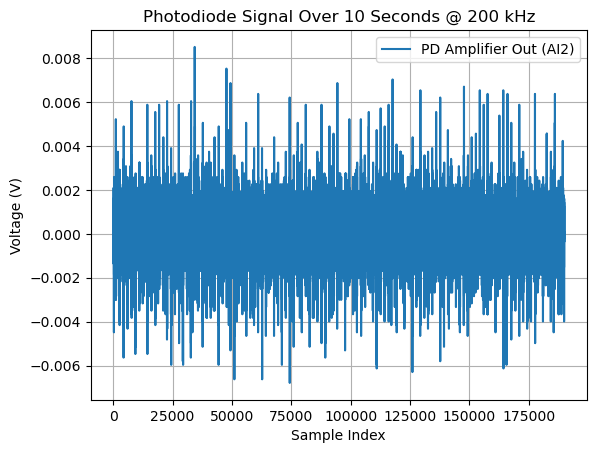

In [50]:
plt.plot(data[10000:200000], label="PD Amplifier Out (AI2)")
plt.xlabel("Sample Index")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.title("Photodiode Signal Over 10 Seconds @ 200 kHz")
plt.show()

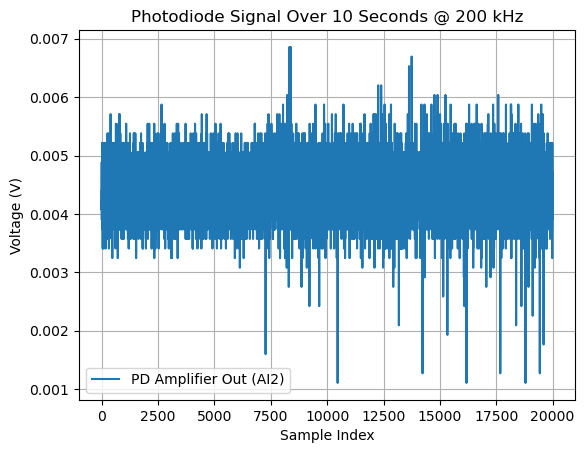

In [36]:
plt.plot(data[::100], label="PD Amplifier Out (AI2)")
plt.xlabel("Sample Index")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.title("Photodiode Signal Over 10 Seconds @ 200 kHz")
plt.show()